In [1]:
from _defs._init_update import *
from _defs.iplot import *

defs version: /mnt/data2/_samplecodes/defs/v20260323
defs is up-to-date.
currentpath:  /mnt/data2/TP_CON/group/PFC/analysis/05_analysis


In [41]:
def hplots_stats(dat,title=[],vmin=0.16,vmax=0.5,savefigpath=0,cmap=0,threshold=0.22):
    # data - n_figures x n_times x n_times
    
    acc = dat['acc']; acc_shuffle = dat['acc_shuffle']
    times = dat['times']; tt = dat['tt'][:2]; ttlabel = dat['ttlabel'][:2]
    
    structure =  [[0,1,0],[1,1,1],[0,1,0]]
    maxcluster=[]
    for i in range(len(acc_shuffle)):
        labeled_array, num_features = label(acc_shuffle[i]>threshold,structure=structure)
        cluster_sizes = np.array([np.sum(labeled_array == i) for i in range(1, num_features + 1)])
        maxcluster.append(cluster_sizes.max())
    maxcluster = np.array(maxcluster).max()
    
    if cmap==0:
        cmap = cm.get_cmap('RdBu_r',5)
    else:
        cmap=cmap
    row=int(np.sqrt(acc.shape[0])); col=int(np.sqrt(acc.shape[0]));

    redrat = 3.6;
    i=0; fs=6*redrat;
    # figsize=6
    fig, ax = plt.subplots(row, col,figsize=(2*redrat,2*redrat))
    for ii in range(row):
        for kk in range(col):
            score = acc[i]
            
            labeled_array, num_features = label(acc[i]>threshold,structure=structure)
            cluster_sizes = np.array([np.sum(labeled_array == j) for j in range(1, num_features + 1)])
            inds = np.where(cluster_sizes>maxcluster)[0]
            la=np.zeros(labeled_array.shape)==1
            for j,ind in enumerate(inds):
                la = (la) | (labeled_array==ind+1)
            
            
            
            im = ax[ii][kk].imshow(score, interpolation='gaussian',origin='lower', cmap=cmap,
                           extent=times[[0, -1, 0, -1]], vmin=vmin, vmax=vmax,aspect='equal')

            ax[ii][kk].contour(la, levels=1, colors='white',origin='lower',linestyles='dashed',
                               alpha=1,extent=times[[0, -1, 0, -1]],linewidths=1)
            ax[ii][kk].set_xticks(tt)
            ax[ii][kk].set_yticks(tt)
            if ii==1: 
                ax[ii][kk].set_xticklabels(ttlabel,fontsize=fs) 
            else: 
                ax[ii][kk].set_xticklabels([],fontsize=fs)
            if kk==0: 
                ax[ii][kk].set_yticklabels(ttlabel,fontsize=fs) 
            else: 
                ax[ii][kk].set_yticklabels([],fontsize=fs)
            
            if kk==0:
                ax[ii][kk].set_ylabel('train time',fontsize=fs)
            if ii==(col-1):
                ax[ii][kk].set_xlabel('test time',fontsize=fs)
            
            ax[ii][kk].set_title('rank'+str(ii+1)+' → rank'+str(kk+1),fontsize=fs)
            ax[ii][kk].spines['top'].set_visible(False)  # Remove top spine
            ax[ii][kk].spines['right'].set_visible(False)  # Remove right spine
            ax[ii][kk].spines['bottom'].set_visible(False)  # Remove bottom spine
            ax[ii][kk].spines['left'].set_visible(False)  # Remove left spine

            
            c = 'w'
            for j in range(len(tt)):
                ax[ii][kk].axvline(tt[j], c=c)
                ax[ii][kk].axhline(tt[j], c=c)
            i=i+1
    
    cbar = plt.colorbar(im, ax=ax,shrink=0.6,anchor=(2,0.49))
    cbar.set_ticks([0.20, 0.25, 0.30])
    cbar.outline.set_visible(False)
    # cbar.set_label('decoding accuracy',fontsize=fs,rotation=90,labelpad=-90,y=0.5)
    cbar.ax.tick_params(labelsize=fs-4)
    if len(title)>0: plt.suptitle(title,x=0.5,y=0.97,fontsize=fs);
    plt.subplots_adjust(wspace = 0.2, hspace = 0.2)
    
    
    if savefigpath!=0:
        plt.savefig(savefigpath, format='pdf', dpi=300, bbox_inches='tight')

    plt.show()


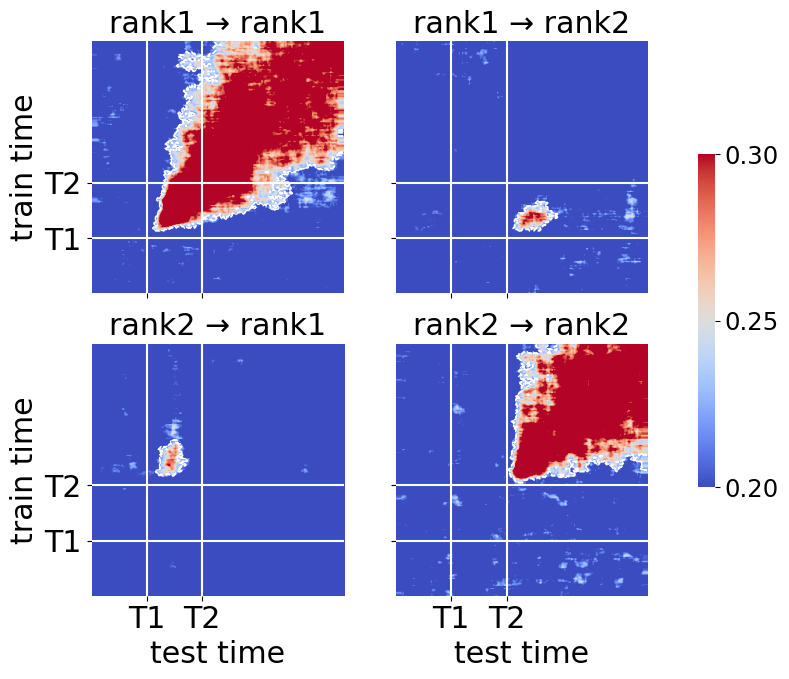

In [42]:
animID = '0239'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
hplots_stats(tempGen, title=[],vmin=0.2,vmax=0.3,savefigpath=outputdir+'/_figs/'+'fig2a.pdf',cmap='coolwarm',threshold=0.22)

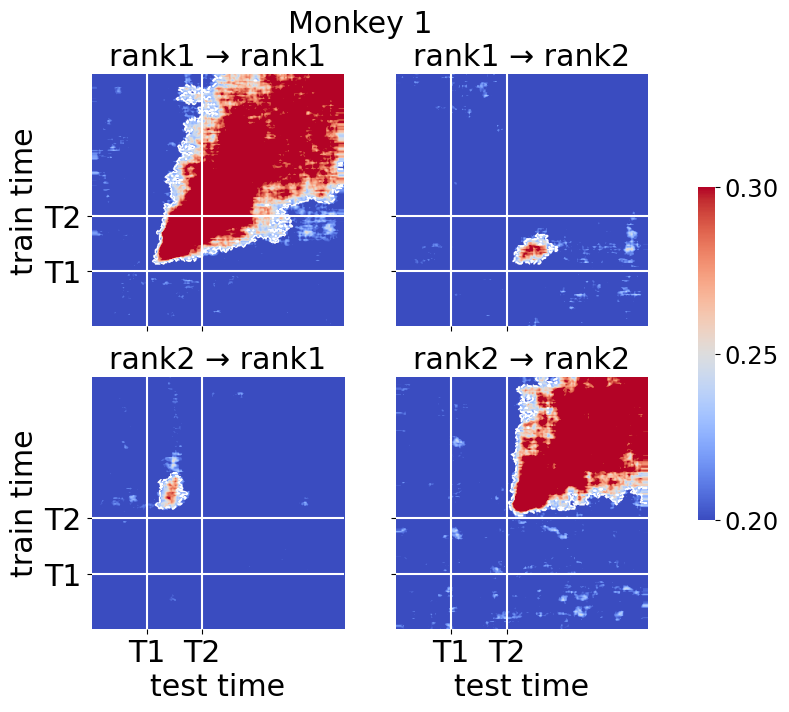

In [48]:
animID = '0239'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
hplots_stats(tempGen, title=tempGen['animName'],vmin=0.2,vmax=0.3,savefigpath=outputdir+'/_figs/'+'figs4a3.pdf',cmap='coolwarm',threshold=0.22)

[    1     2     3     5     6     7     9    18    26    30 11853] 26.0
[  1   2   6  11 242] 57.20000000000004
[  1   2   6   8 192] 44.80000000000003
[   1    2    3    4   12   19 7605] 17.600000000000005
0.19999999999999996 0.7666666666666668
0.25 0.9833333333333334


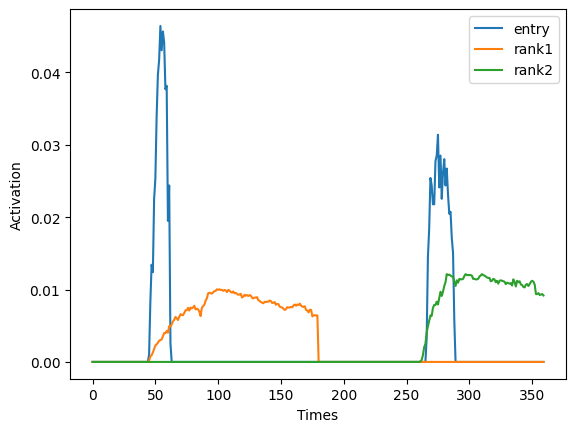

In [21]:
animID = '0239'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
pmodels = pmodel(tempGen['acc'],accthres=0.24,percentile=80,isplot=False)

x = pmodels[0][:tempGen['t2']]
thr = 1e-6   # 或者更大的阈值

idx = np.where(x > thr)[0]

onset  = idx[0]/tempGen['sftp'] - tempGen['T1On']
offset = idx[-1]/tempGen['sftp'] - tempGen['T1On']

print(onset, offset)

x = pmodels[0][tempGen['t2']:]
thr = 1e-6   # 或者更大的阈值

idx = np.where(x > thr)[0]

onset  = idx[0]/tempGen['sftp'] - tempGen['T2On']
offset = idx[-1]/tempGen['sftp'] - tempGen['T2On']

print(onset, offset)

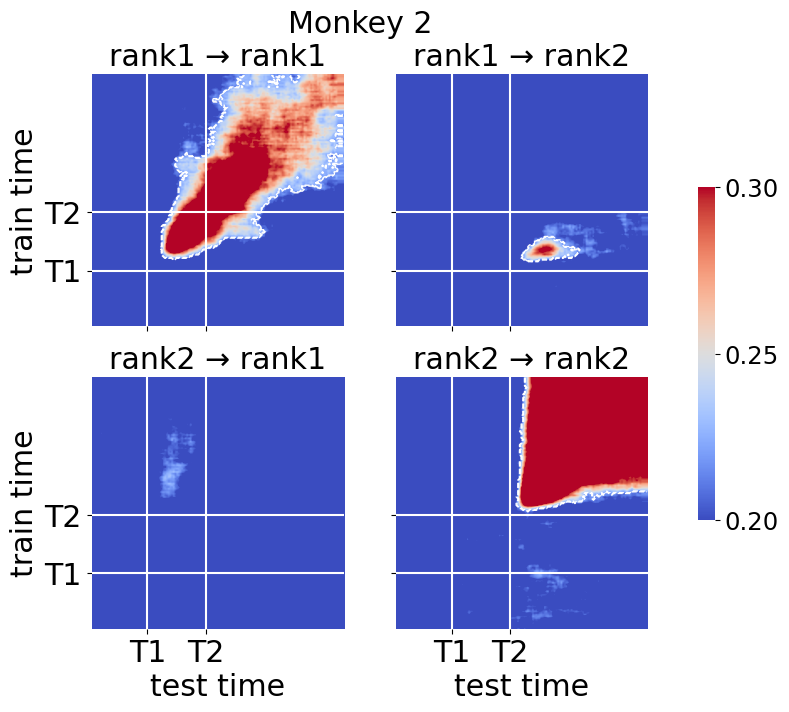

In [47]:
animID = '2019'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
hplots_stats(tempGen, title=tempGen['animName'],vmin=0.2,vmax=0.3,savefigpath=outputdir+'/_figs/'+'figs4a1.pdf',cmap='coolwarm',threshold=0.22)

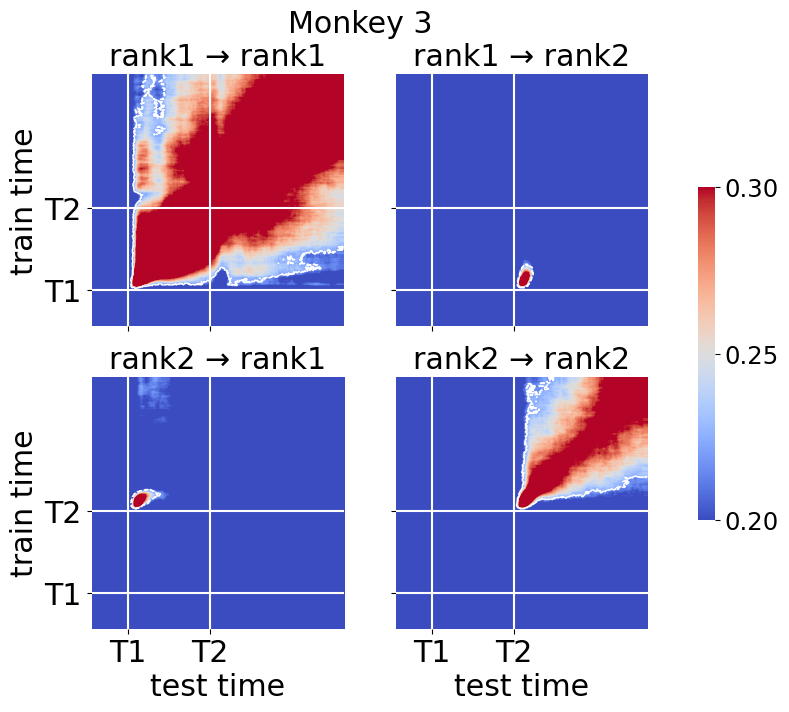

In [49]:
animID = 'groot'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
hplots_stats(tempGen, title=tempGen['animName'],vmin=0.2,vmax=0.3,savefigpath=outputdir+'/_figs/'+'figs4a2.pdf',cmap='coolwarm',threshold=0.22)

[    1     2     3     4     5     6    18 72996] 13.200000000000006
[363] 363.0
[421] 421.0
[    1     2     3     4     6     7     9 22859] 8.200000000000001
0.040000000000000036 0.33999999999999997
0.046666666666666634 0.2666666666666666


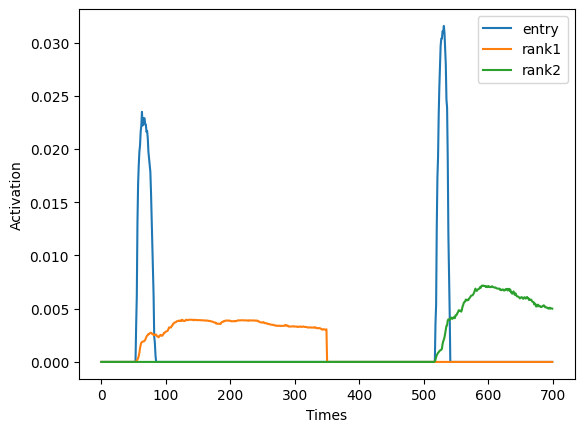

In [23]:
animID = 'groot'; tempGen = load_dictionary_pickle(outputdir+'/tempGen_'+animID+'.pkl')
pmodels = pmodel(tempGen['acc'],accthres=0.24,percentile=80,isplot=False)

x = pmodels[0][:tempGen['t2']]
thr = 1e-6   # 或者更大的阈值

idx = np.where(x > thr)[0]

onset  = idx[0]/tempGen['sftp'] - tempGen['T1On']
offset = idx[-1]/tempGen['sftp'] - tempGen['T1On']

print(onset, offset)

x = pmodels[0][tempGen['t2']:]
thr = 1e-6   # 或者更大的阈值

idx = np.where(x > thr)[0]

onset  = idx[0]/tempGen['sftp'] - tempGen['T2On']
offset = idx[-1]/tempGen['sftp'] - tempGen['T2On']

print(onset, offset)

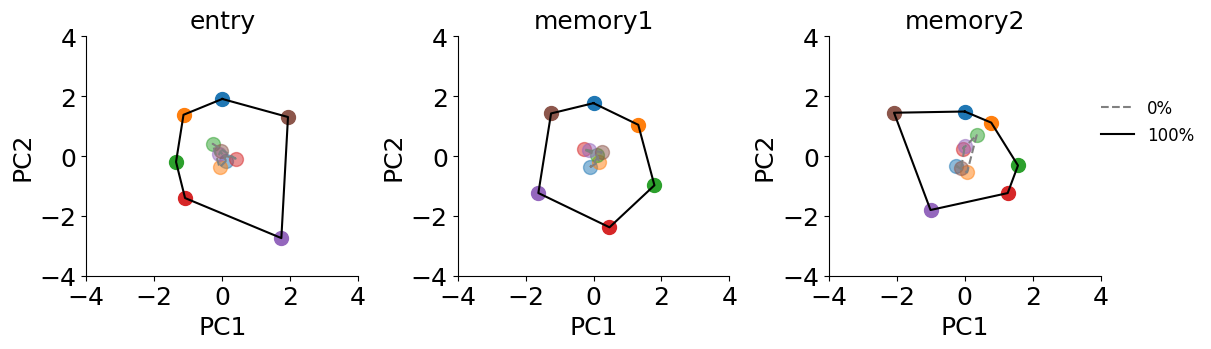

In [32]:
animID = '0239';ssDat = load_dictionary_pickle(outputdir+'/ssDat_full_'+animID+'.pkl')


titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','100%'];lss=['--','-']
colors2=['gray','k','gray','k','gray','k'];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/fig2b.pdf', format='pdf', dpi=300, bbox_inches='tight')

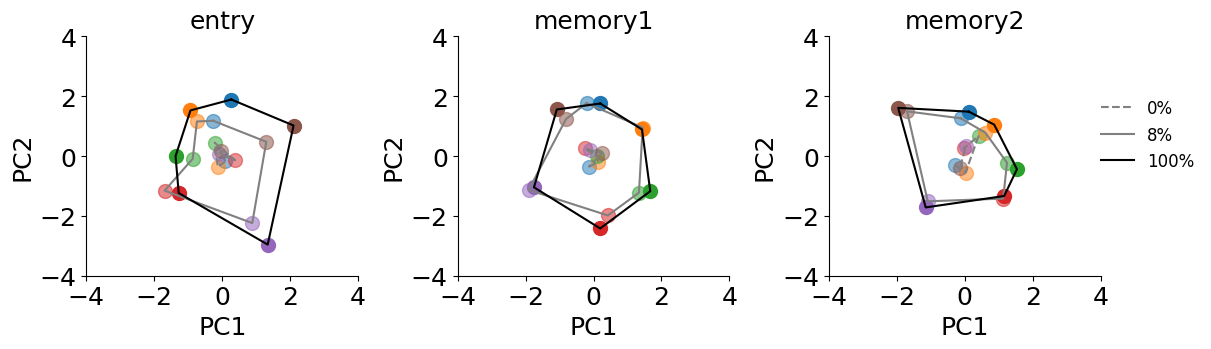

In [34]:
animID = '0239';ssDat = load_dictionary_pickle(outputdir+'/ssDat_full3_'+animID+'.pkl')

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','8%','100%']
lss=['--','-','-']
colors2=["gray", "gray", "k", 
          "gray", "gray", "k", 
          "gray", "gray", "k",];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs4b1.pdf', format='pdf', dpi=300, bbox_inches='tight')

adaptive k value (E, R1, R2): [13, 8, 5]
adaptive k value (E, R1, R2): [13, 8, 5]


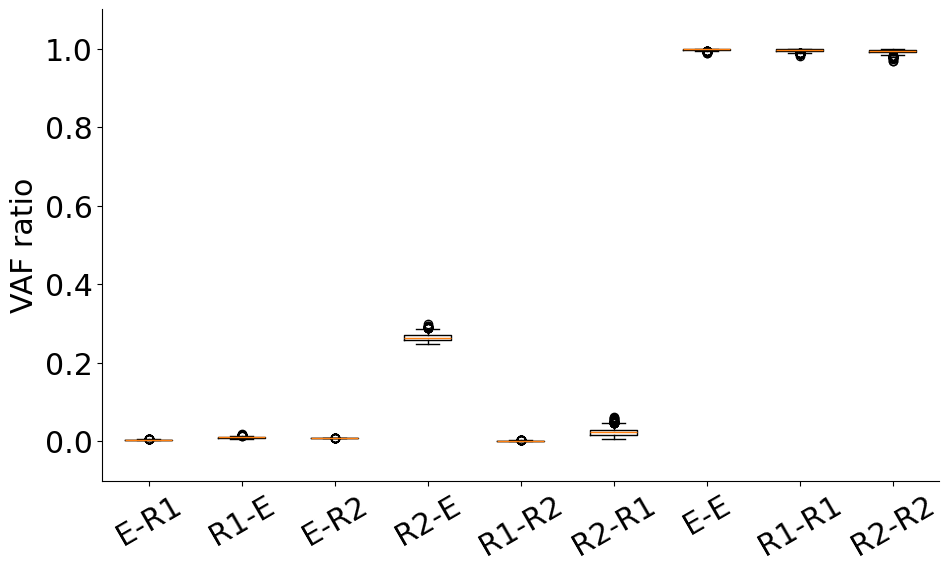

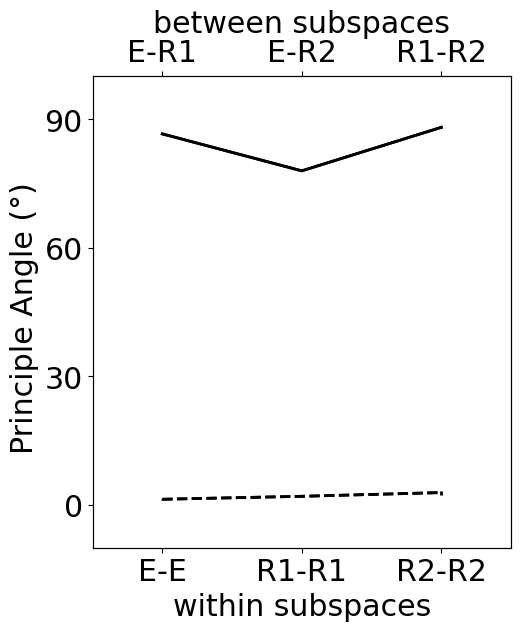

In [6]:
animID = '0239';ssDat = load_dictionary_pickle(outputdir+'/ssDat_full2_'+animID+'.pkl')
vafs_L = subspace_vaf(ssDat['coefs'], N=1000, k_ratio=0.02, seed=42); 
degs_L = subspace_pcangle(ssDat['latents'], N=1000, k_ratio=0.02, seed=42)
fig1,fig2 = subspace_relplot(vafs_L,degs_L)

fig1.savefig(outputdir+'/_figs/figs4d1.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs4c1.pdf', format='pdf', dpi=300, bbox_inches='tight')

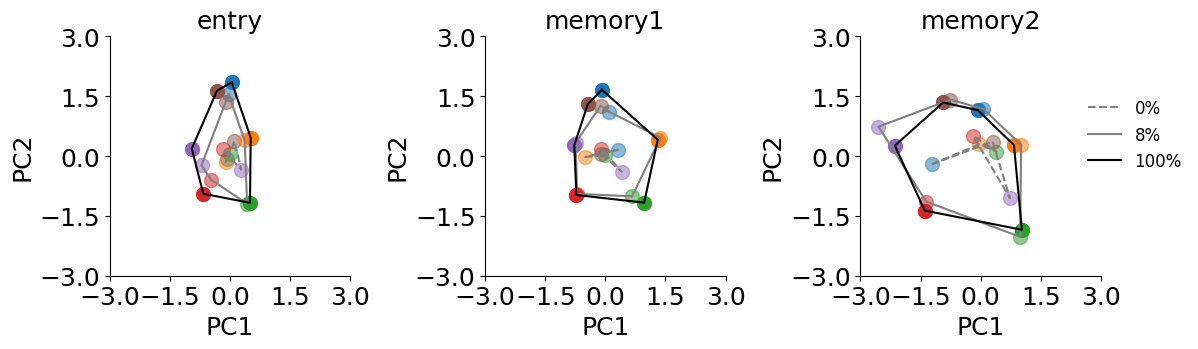

In [9]:
animID = '2019';ssDat = load_dictionary_pickle(outputdir+'/ssDat_full_'+animID+'.pkl')
p = np.array([True, False, True, False, True])
e = np.concatenate([ssDat['xys'][0:1,0:1],ssDat['xys'][0:1,1:3].mean(1,keepdims=True),ssDat['xys'][0:1,3:5].mean(1,keepdims=True)],axis=1)
r1 = np.concatenate([ssDat['xys'][1:2,0:1],ssDat['xys'][1:2,1:3].mean(1,keepdims=True),ssDat['xys'][1:2,3:5].mean(1,keepdims=True)],axis=1)
r2 = np.concatenate([ssDat['xys'][2:3,0:1],ssDat['xys'][2:3,1:3].mean(1,keepdims=True),ssDat['xys'][2:3,3:5].mean(1,keepdims=True)],axis=1)

ssDat['xys'] = np.concatenate([e,r1,r2])
ssDat['label2'] = ssDat['label2'][p]

titles=['entry','memory1','memory2'];xyscl=[3,3,3]
legnd=['0%','8%','100%']
lss=['--','-','-']
colors2=["gray", "gray", "k", 
          "gray", "gray", "k", 
          "gray", "gray", "k",];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs4b2.pdf', format='pdf', dpi=300, bbox_inches='tight')

adaptive k value (E, R1, R2): [41, 24, 17]
adaptive k value (E, R1, R2): [41, 24, 17]


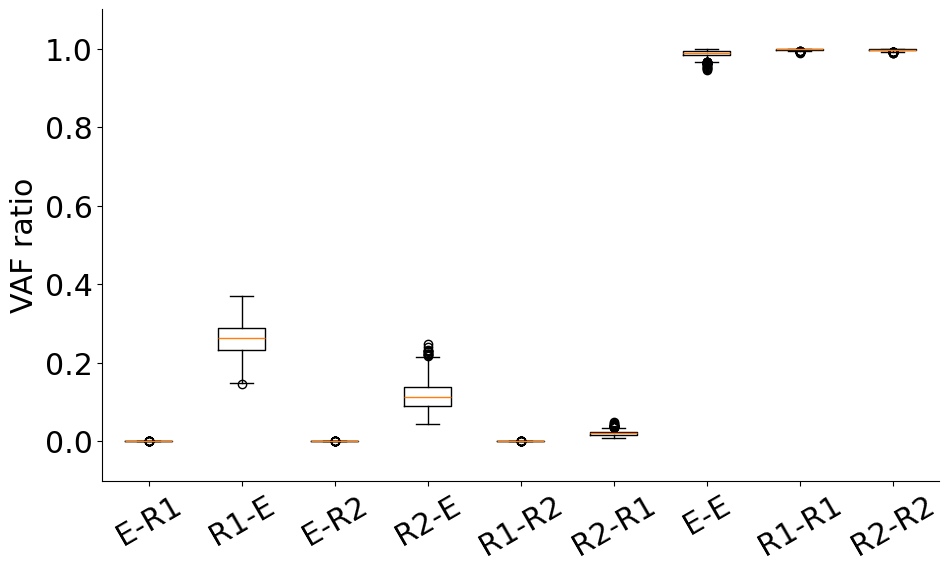

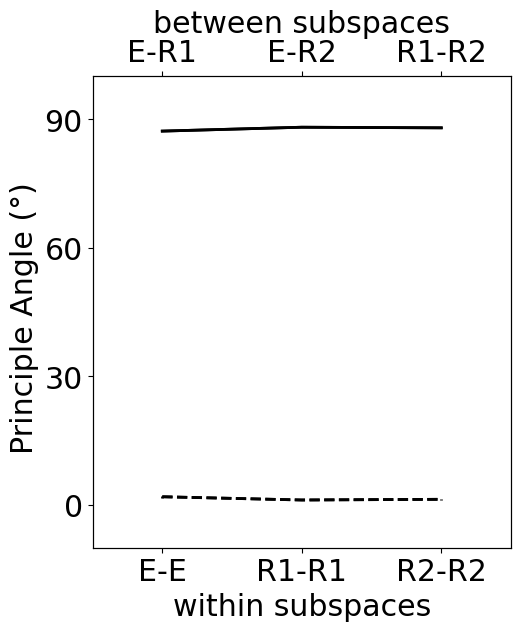

In [11]:
animID = '2019';ssDat = load_dictionary_pickle(outputdir+'/ssDat_full2_'+animID+'.pkl')
vafs_L = subspace_vaf(ssDat['coefs'], N=1000, k_ratio=0.02, seed=42); 
degs_L = subspace_pcangle(ssDat['latents'], N=1000, k_ratio=0.02, seed=42)
fig1,fig2 = subspace_relplot(vafs_L,degs_L)

fig1.savefig(outputdir+'/_figs/figs4d2.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs4c2.pdf', format='pdf', dpi=300, bbox_inches='tight')

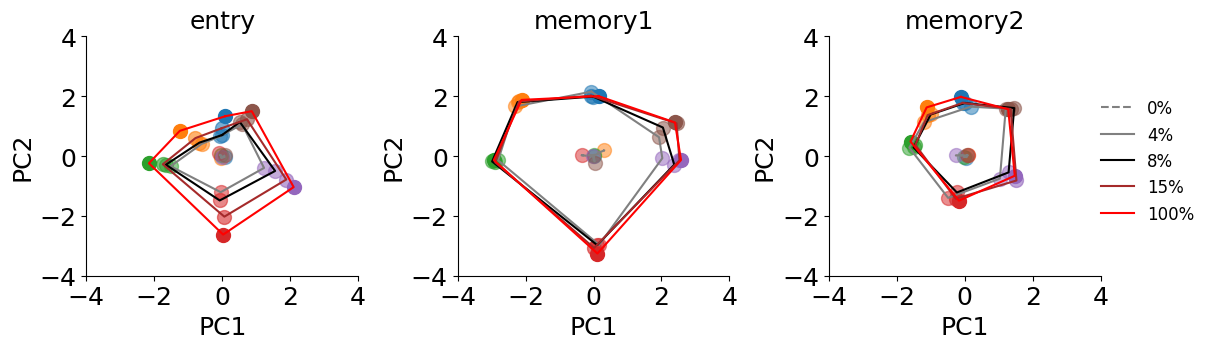

In [39]:
animID = 'groot';ssDat = load_dictionary_pickle(outputdir+'/ssDat_all_'+animID+'.pkl')

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','4%','8%','15%','100%']
lss=['--','-','-','-','-']
colors2=["gray", "gray", "k", "brown", "red",
          "gray", "gray", "k", "brown", "red",
          "gray", "gray", "k", "brown", "red"];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs4b.pdf', format='pdf', dpi=300, bbox_inches='tight')

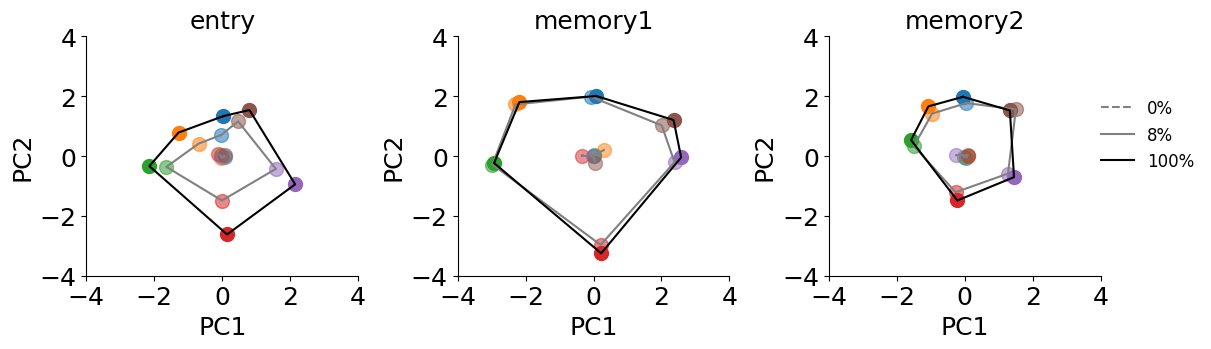

In [45]:
animID = 'groot';ssDat = load_dictionary_pickle(outputdir+'/ssDat_all_'+animID+'.pkl')

p = np.array([True, False, True, False, True])
ssDat['xys'] = ssDat['xys'][:,p]
ssDat['label2'] = ssDat['label2'][p]

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','8%','100%']
lss=['--','-','-']
colors2=["gray", "gray", "k", 
          "gray", "gray", "k", 
          "gray", "gray", "k",];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs4b3.pdf', format='pdf', dpi=300, bbox_inches='tight')

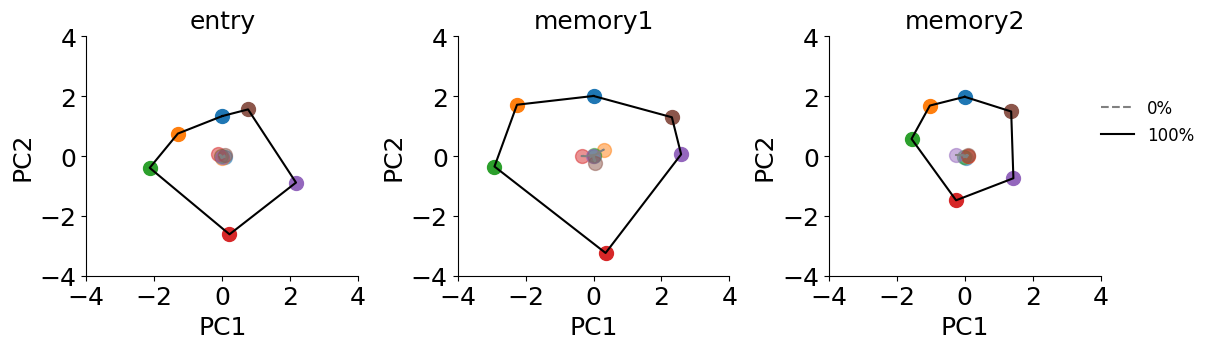

In [3]:
animID = 'groot';ssDat = load_dictionary_pickle(outputdir+'/ssDat_all_'+animID+'.pkl')

p = np.array([True, False, False, False, True])
ssDat['xys'] = ssDat['xys'][:,p]
ssDat['label2'] = ssDat['label2'][p]

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','100%']
lss=['--','-']
colors2=["gray", "k", 
          "gray", "k",
          "gray", "k"];

fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
# fig.savefig(outputdir+'/_figs/figs4b.pdf', format='pdf', dpi=300, bbox_inches='tight')

adaptive k value (E, R1, R2): [284, 152, 132]
adaptive k value (E, R1, R2): [284, 152, 132]


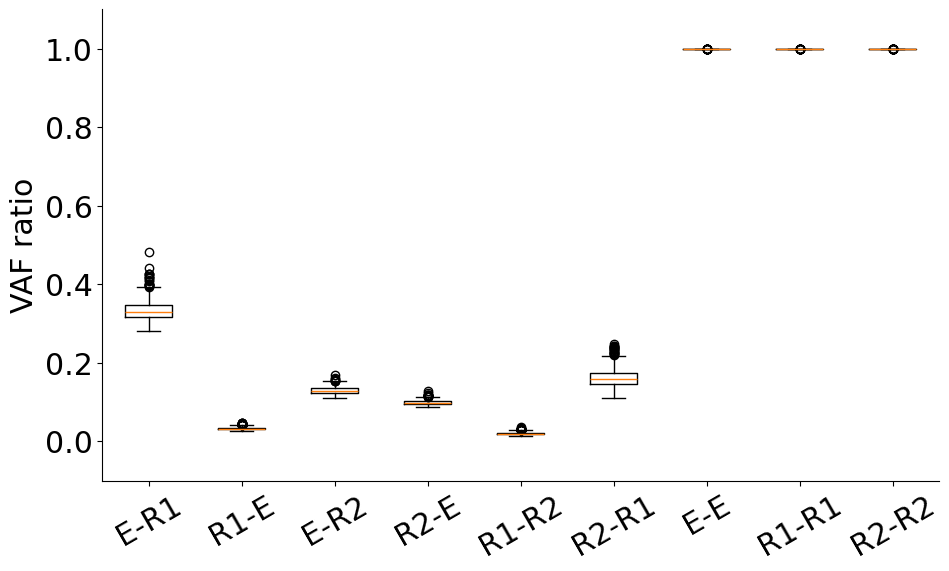

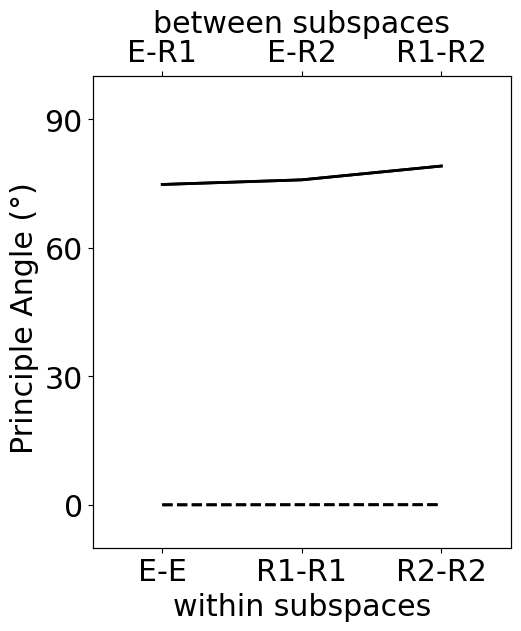

In [3]:
vafs_L = subspace_vaf(ssDat['coefs'], N=1000, k_ratio=0.02, seed=42); 
degs_L = subspace_pcangle(ssDat['latents'], N=1000, k_ratio=0.02, seed=42)
fig1,fig2 = subspace_relplot(vafs_L,degs_L)

fig1.savefig(outputdir+'/_figs/figs4c3.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs4d3.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [ ]:
### project 0% response trials to state space models trained by 100% contrast

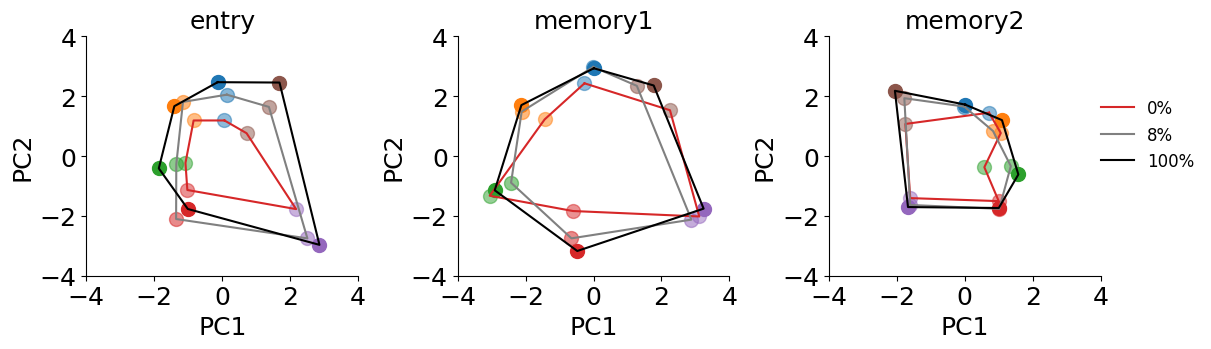

In [2]:
animID = '0239';ssDat = load_dictionary_pickle(outputdir+'/ssDat_rsp_'+animID+'.pkl')

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','8%','100%']
lss=['-','-','-']

colors2=[colors[3],[0.5,0.5,0.5],'k',
         colors[3],[0.5,0.5,0.5],'k',
        colors[3],[0.5,0.5,0.5],'k']
fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs5a1.pdf', format='pdf', dpi=300, bbox_inches='tight')

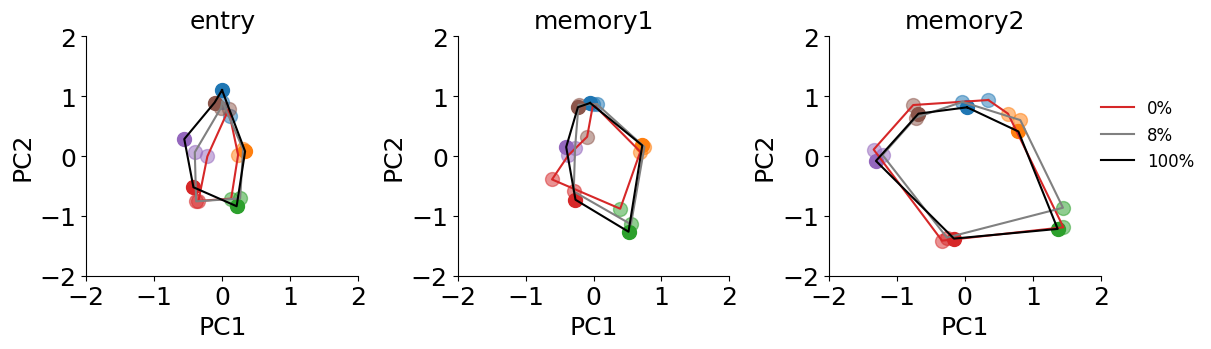

In [3]:
animID = '2019';ssDat = load_dictionary_pickle(outputdir+'/ssDat_rsp_'+animID+'.pkl')

titles=['entry','memory1','memory2'];xyscl=[2,2,2]
legnd=['0%','8%','100%']
lss=['-','-','-']

colors2=[colors[3],[0.5,0.5,0.5],'k',
         colors[3],[0.5,0.5,0.5],'k',
        colors[3],[0.5,0.5,0.5],'k']
fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs5a2.pdf', format='pdf', dpi=300, bbox_inches='tight')

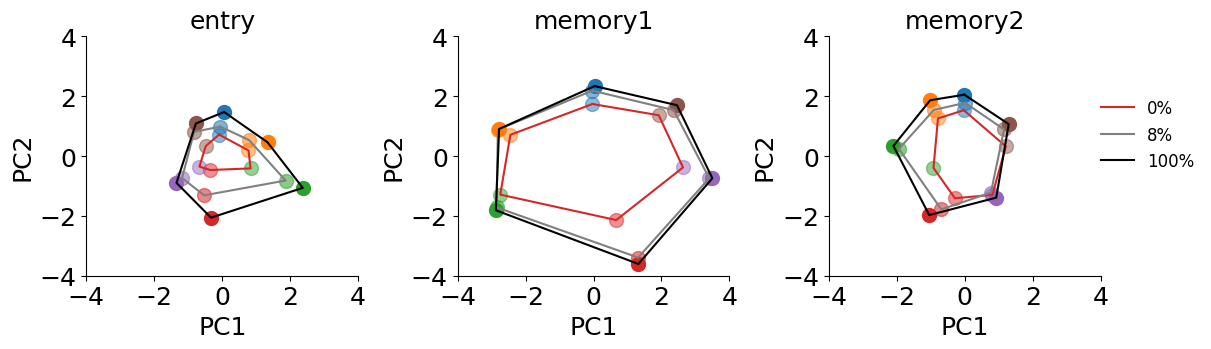

In [4]:
animID = 'groot';ssDat = load_dictionary_pickle(outputdir+'/ssDat_rsp_'+animID+'.pkl')

titles=['entry','memory1','memory2'];xyscl=[4,4,4]
legnd=['0%','8%','100%']
lss=['-','-','-']

colors2=[colors[3],[0.5,0.5,0.5],'k',
         colors[3],[0.5,0.5,0.5],'k',
        colors[3],[0.5,0.5,0.5],'k']
fig = ssplot(ssDat,titles,colors2,lss,xyscl,legnd);
fig.savefig(outputdir+'/_figs/figs5a3.pdf', format='pdf', dpi=300, bbox_inches='tight')

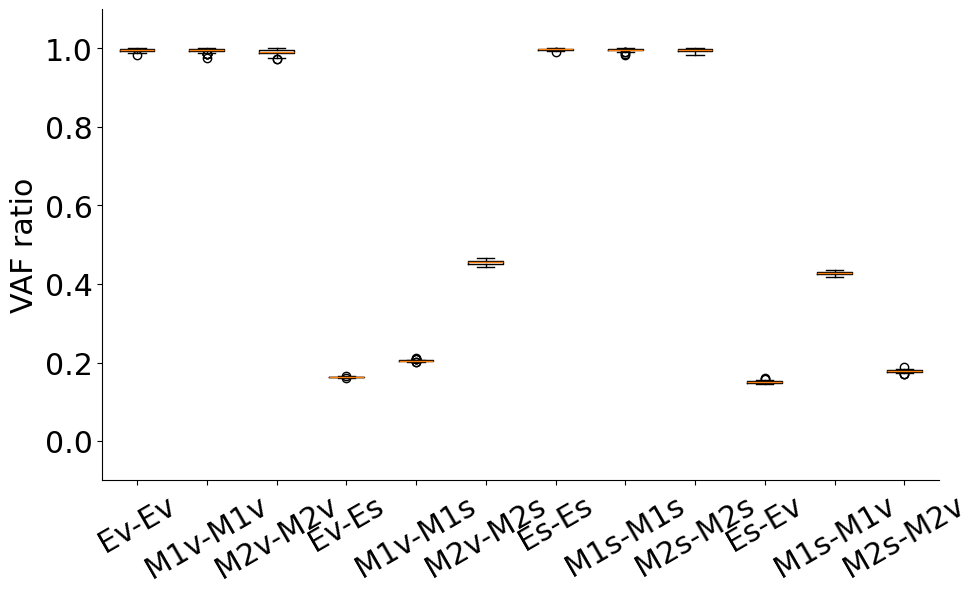

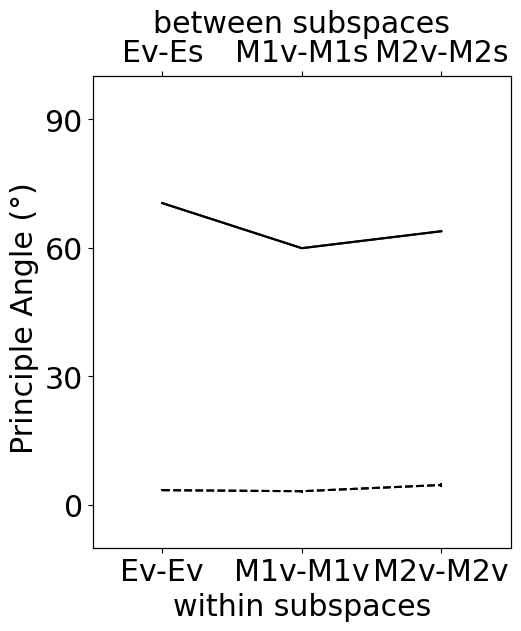

In [5]:
dat = load_dictionary_pickle(outputdir+'/vol_subspace_0239.pkl')
fig1,fig2 = subspace_rel2plot(dat['vafs_L'],dat['degs_L'])
fig1.savefig(outputdir+'/_figs/figs5c1.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs5d1.pdf', format='pdf', dpi=300, bbox_inches='tight')

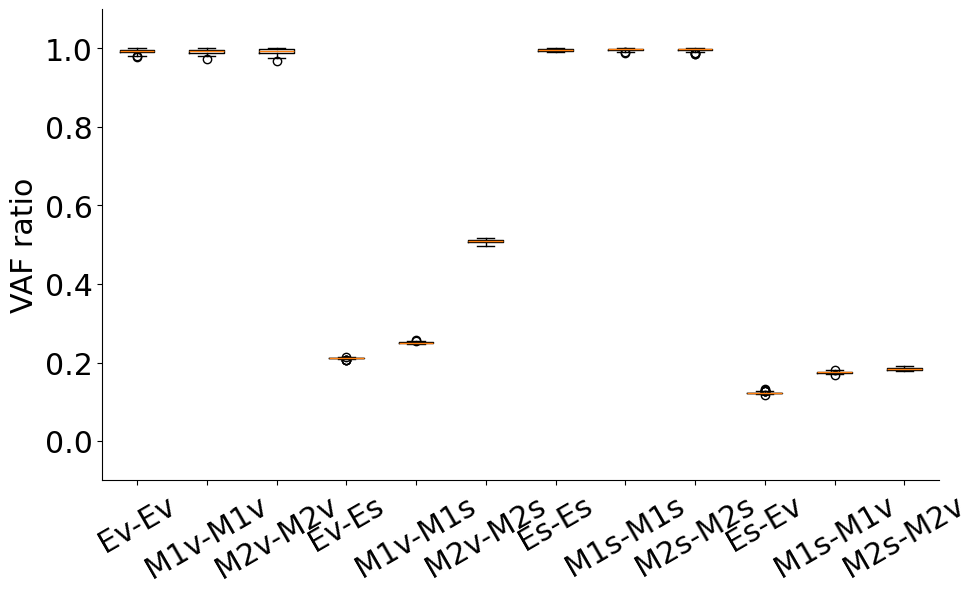

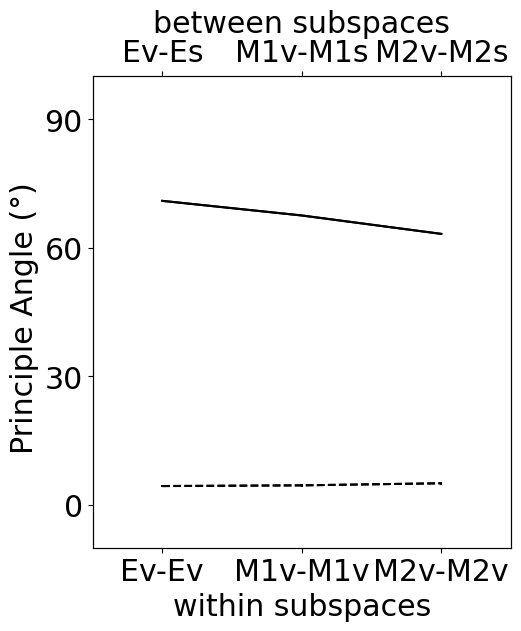

In [6]:
dat = load_dictionary_pickle(outputdir+'/vol_subspace_2019.pkl')
fig1,fig2 = subspace_rel2plot(dat['vafs_L'],dat['degs_L'])
fig1.savefig(outputdir+'/_figs/figs5c2.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs5d2.pdf', format='pdf', dpi=300, bbox_inches='tight')

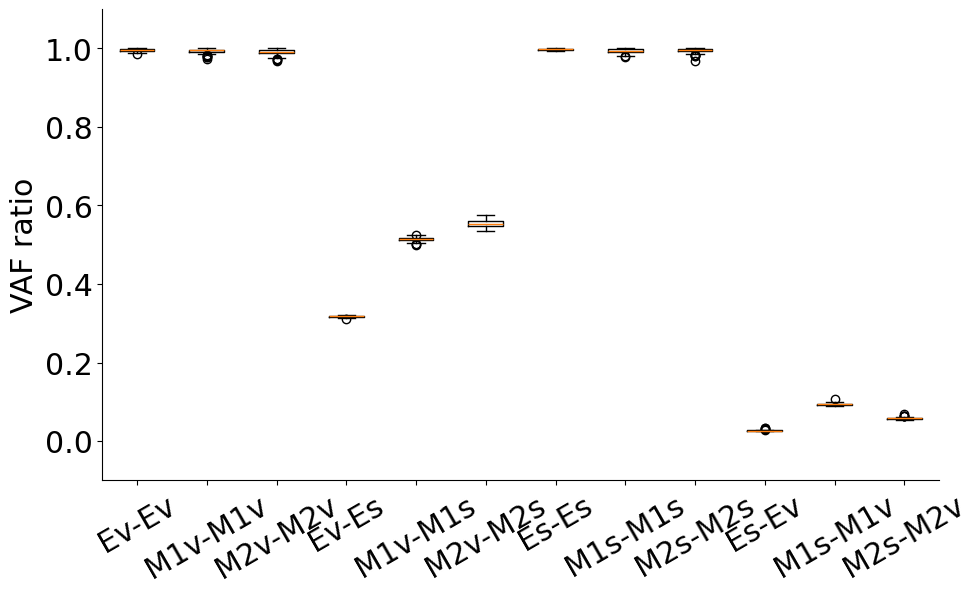

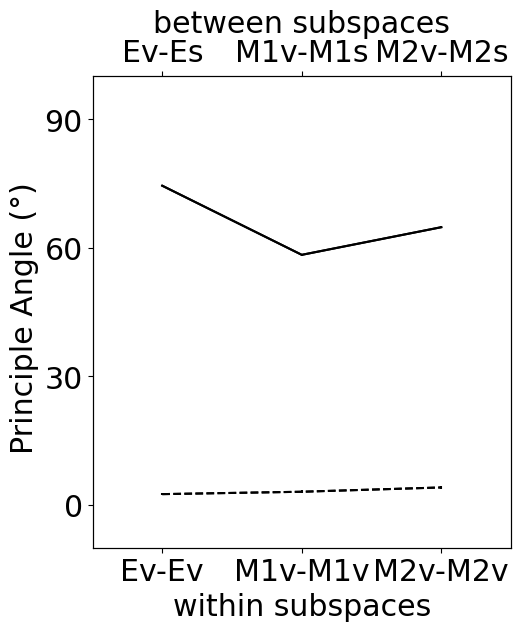

In [7]:
dat = load_dictionary_pickle(outputdir+'/vol_subspace_groot.pkl')
fig1,fig2 = subspace_rel2plot(dat['vafs_L'],dat['degs_L'])
fig1.savefig(outputdir+'/_figs/figs5c3.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig2.savefig(outputdir+'/_figs/figs5d3.pdf', format='pdf', dpi=300, bbox_inches='tight')